# ============================================================
# Imports
# ============================================================

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
file_path = "heart_failure_clinical_records_dataset.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "andrewmvd/heart-failure-clinical-data",
    file_path
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

100%|██████████| 12.0k/12.0k [00:00<00:00, 8.27MB/s]

Dataset loaded successfully!
Shape: (299, 13)


In [4]:
print("First 5 records:")
print(df.head())

First 5 records:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6       

In [5]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 299
Number of columns: 13


In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [9]:
print("Data types:")
print(df.dtypes)

Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


## ============================================================
## VISUALIZE MISSING VALUES
## ============================================================

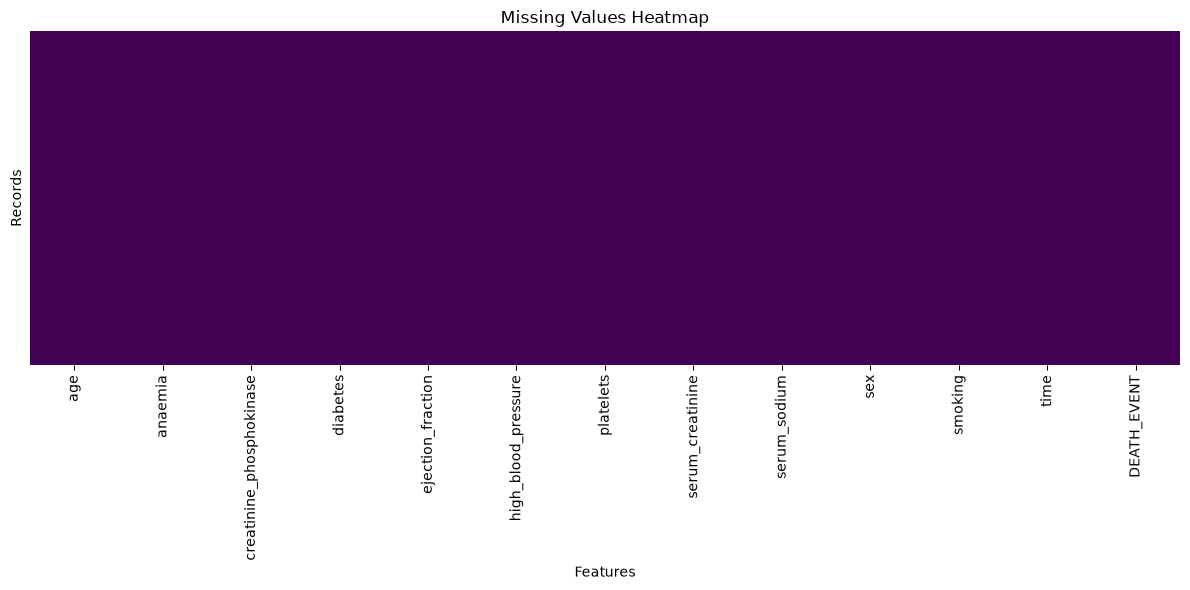

In [10]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Records")
plt.tight_layout()
plt.show()

## ============================================================
## 5. PLOT DISTRIBUTIONS
## ============================================================

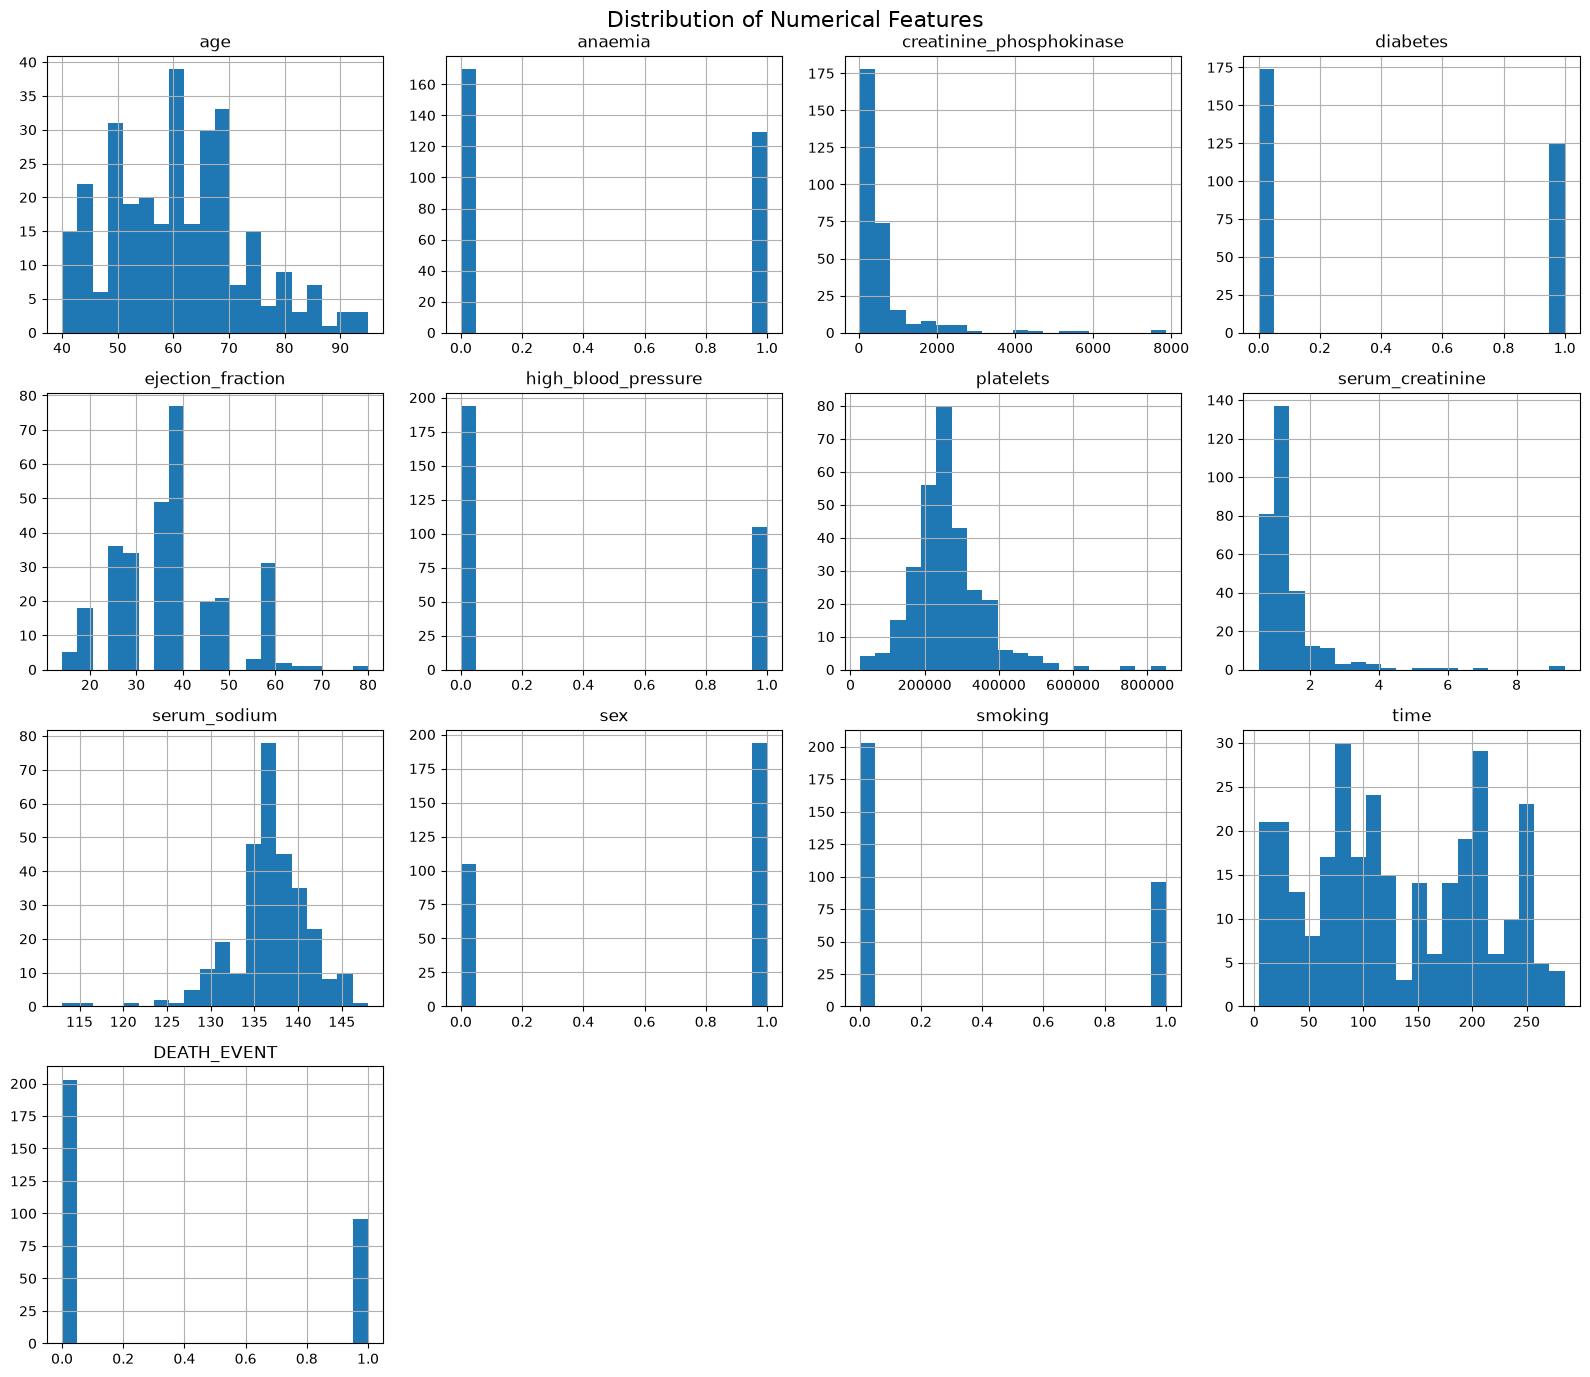

In [11]:
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

df[numerical_features].hist(
    figsize=(16, 14),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

## ============================================================
## 6. IMPUTE MISSING VALUES
## ============================================================

In [12]:
categorical_features = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Numerical features -> Median
for column in numerical_features:
    df[column] = df[column].fillna(df[column].median())

# Categorical features -> Mode
for column in categorical_features:
    df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


## ============================================================
##                      REMOVING OUTLIERS
## ============================================================

In [13]:
df_clean = df.copy()

for column in numerical_features:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[column] >= lower_bound) &
        (df_clean[column] <= upper_bound)
    ]

print("\nOriginal dataset shape:", df.shape)
print("After outlier removal:", df_clean.shape)


Original dataset shape: (299, 13)
After outlier removal: (224, 13)


## ============================================================
## 8. CORRECT INCONSISTENCIES
## ============================================================

In [14]:
print("\nChecking for negative values:")

for column in numerical_features:

    negative_count = (df_clean[column] < 0).sum()

    if negative_count > 0:
        print(
            column,
            "has",
            negative_count,
            "negative values"
        )

# Correct invalid negative age values
df_clean.loc[df_clean["age"] < 0, "age"] = np.nan

# Fill corrected age values
df_clean["age"] = df_clean["age"].fillna(
    df_clean["age"].median()
)

print("Inconsistency checking completed.")


Checking for negative values:
Inconsistency checking completed.


## ============================================================
## 9. FEATURE ENGINEERING
## ============================================================

In [15]:
# -------- Age Group --------

def create_age_group(age):

    if age < 40:
        return "<40"

    elif age <= 60:
        return "40-60"

    else:
        return ">60"


df_clean["age_group"] = df_clean["age"].apply(
    create_age_group
)

print("\nAge Group:")
print(df_clean["age_group"].value_counts())


# -------- Risk Score --------

df_clean["risk_score_raw"] = (
    df_clean["ejection_fraction"] *
    df_clean["serum_creatinine"]
)

risk_scaler = MinMaxScaler()

df_clean["risk_score"] = risk_scaler.fit_transform(
    df_clean[["risk_score_raw"]]
)

df_clean.drop(
    columns=["risk_score_raw"],
    inplace=True
)

print("\nRisk Score created successfully.")




Age Group:
age_group
40-60    115
>60      109
Name: count, dtype: int64

Risk Score created successfully.


## ============================================================
## 10. ENCODE CATEGORICAL VARIABLES
## ============================================================

In [16]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["age_group"],
    drop_first=True
)

# Convert Boolean values to integers
boolean_columns = df_clean.select_dtypes(
    include=["bool"]
).columns

df_clean[boolean_columns] = df_clean[
    boolean_columns
].astype(int)

print("\nCategorical variables encoded.")


Categorical variables encoded.


## ============================================================
## 11. NORMALIZE NUMERICAL FEATURES
## ============================================================

In [17]:
features_to_scale = [
    column
    for column in numerical_features
    if column != "DEATH_EVENT"
]

scaler = MinMaxScaler()

df_clean[features_to_scale] = scaler.fit_transform(
    df_clean[features_to_scale]
)

print("\nNumerical features normalized.")


Numerical features normalized.


## ============================================================
## 12. SUMMARY STATISTICS
## ============================================================

In [18]:
print("\nStatistics BEFORE cleaning:")

print(
    df[numerical_features].describe().T[
        ["mean", "50%", "std"]
    ]
)


print("\nStatistics AFTER cleaning:")

print(
    df_clean[numerical_features].describe().T[
        ["mean", "50%", "std"]
    ]
)


Statistics BEFORE cleaning:
                                   mean       50%           std
age                           60.833893      60.0     11.894809
anaemia                        0.431438       0.0      0.496107
creatinine_phosphokinase     581.839465     250.0    970.287881
diabetes                       0.418060       0.0      0.494067
ejection_fraction             38.083612      38.0     11.834841
high_blood_pressure            0.351171       0.0      0.478136
platelets                 263358.029264  262000.0  97804.236869
serum_creatinine               1.393880       1.1      1.034510
serum_sodium                 136.625418     137.0      4.412477
sex                            0.648829       1.0      0.478136
smoking                        0.321070       0.0      0.467670
time                         130.260870     115.0     77.614208
DEATH_EVENT                    0.321070       0.0      0.467670

Statistics AFTER cleaning:
                              mean       50%   

## ============================================================
## 13. VALIDATE CLEANING
## ============================================================

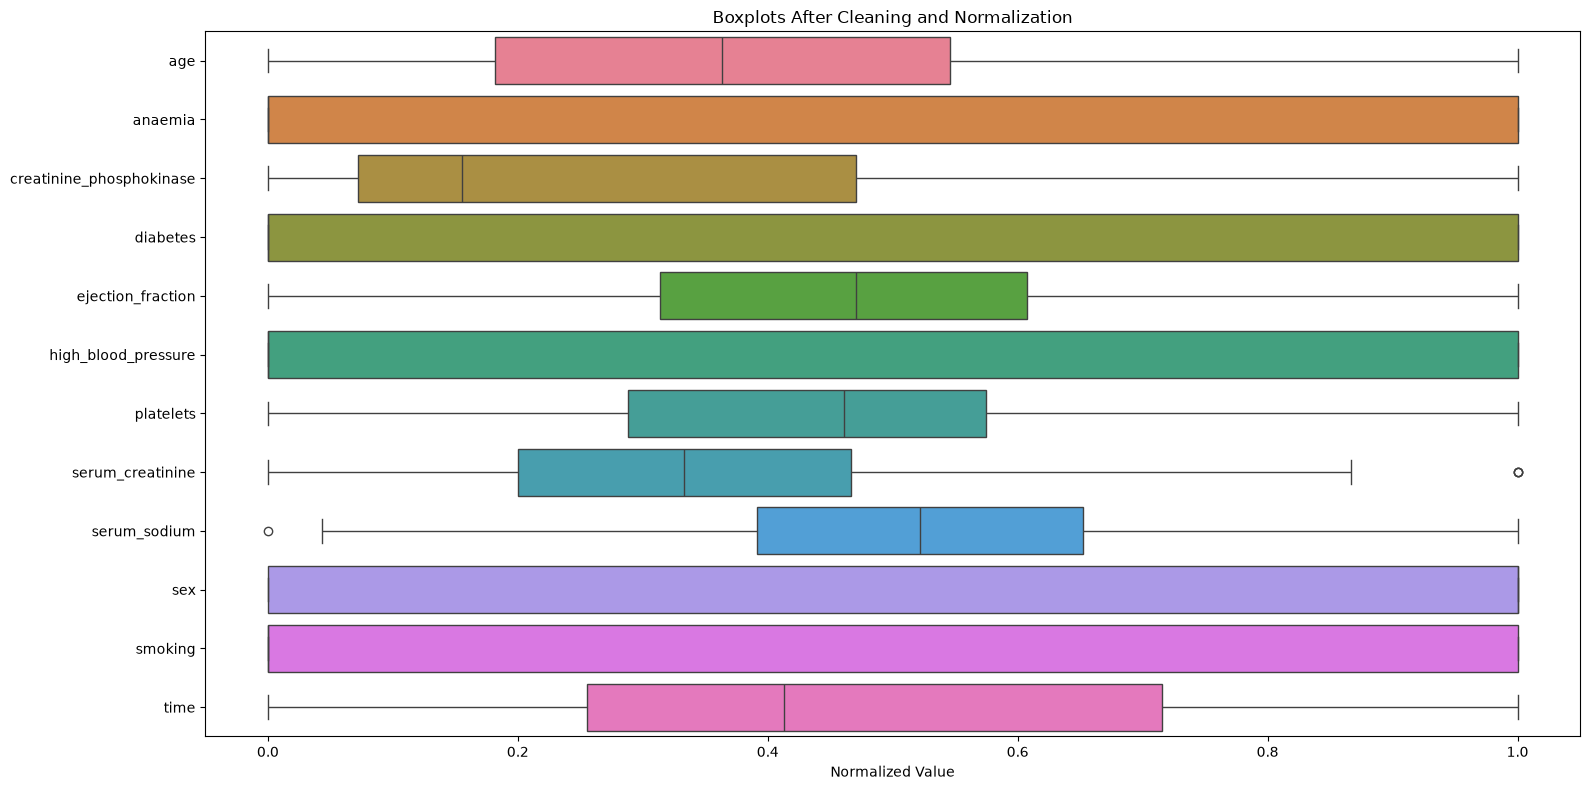

In [19]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=df_clean[features_to_scale],
    orient="h"
)

plt.title(
    "Boxplots After Cleaning and Normalization"
)

plt.xlabel("Normalized Value")

plt.tight_layout()
plt.show()

## ============================================================
## 14. CHECK MISSING VALUES
## ============================================================

In [20]:
print("\nFinal Missing Values:")

print(df_clean.isnull().sum())

if df_clean.isnull().sum().sum() == 0:

    print(
        "\nSUCCESS: No missing values remain."
    )

else:

    print(
        "\nSome missing values still remain."
    )



Final Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_>60               0
dtype: int64

SUCCESS: No missing values remain.


## ============================================================
## FINAL DATASET
## ============================================================

In [21]:
print("\nFinal Dataset Shape:")
print(df_clean.shape)

print("\nFinal Dataset:")
print(df_clean.head())


Final Dataset Shape:
(224, 15)

Final Dataset:
        age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  0.636364      0.0                  0.470990       0.0           0.117647   
2  0.454545      0.0                  0.098976       0.0           0.117647   
3  0.181818      1.0                  0.069113       0.0           0.117647   
5  0.909091      1.0                  0.014505       0.0           0.509804   
6  0.636364      1.0                  0.184300       0.0           0.019608   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                  1.0   0.468852          0.866667      0.217391  1.0   
2                  0.0   0.131148          0.466667      0.173913  1.0   
3                  0.0   0.288525          0.866667      0.521739  1.0   
5                  1.0   0.268852          1.000000      0.304348  1.0   
6                  0.0   0.016393          0.400000      0.521739  1.0   

   smoking      time  DEATH_EVEN

## ============================================================
## SAVE CLEANED DATASET
## ============================================================

In [22]:
df_clean.to_csv(
    "heart_failure_cleaned.csv",
    index=False
)

print(
    "\nCleaned dataset saved as "
    "'heart_failure_cleaned.csv'"
)


Cleaned dataset saved as 'heart_failure_cleaned.csv'
